# Credit Card Fraud Detection - AIM ML Capstone
## Step 5: Critical Thinking -> Ethical AI & Bias Auditing

**Author:** Erickson Tan  
**Institution:** Asian Institute of Management  
**Dataset:** ULB Credit Card Fraud Detection (Kaggle)  
**Environment:** Google Colab (Python 3.x)

---

### About This Notebook

This notebook is **fully self-contained** — it does not depend on the Step 3+4 notebook being open in the same session. It re-runs the complete data preparation and model training pipeline from scratch before performing the ethical audit.

**Estimated runtime:** 5-8 minutes (pipeline re-run + SHAP computation)

### Before Running
Upload `creditcard.csv` to the Colab `/content/` folder via the Files panel (folder icon in the left sidebar).

### Notebook Structure

| Section | Content |
|---|---|
| 1 | Self-contained pipeline (data loading -> model training) |
| 2 | Explainability - SHAP for the production model |
| 3 | Limitations - documented with severity and mitigations |
| 4 | Bias Audit 1 - Transaction Amount segments |
| 5 | Bias Audit 2 - Time of Day segments |
| 6 | Fairness Metrics - Demographic Parity, Equalised Odds, Disparate Impact |
| 7 | Proposed Mitigations |
| 8 | Step 5 Summary |


---
## Section 1: Self-Contained Pipeline Setup

This section re-runs the complete pipeline from Steps 3 and 4 so that this notebook can be executed independently in any fresh Colab session.

**What this section does:**
1. Installs required libraries
2. Loads and cleans `creditcard.csv`
3. Applies feature engineering and selects the 15 consensus features
4. Splits into train/test sets
5. Trains XGBoost on the original imbalanced data (the recommended production model)

The feature set (15 features) and model (XGBoost | Original) are hardcoded based on the consensus findings from Step 3 feature selection and Step 4 model evaluation, there is no need to re-run the full SHAP, MI, and RF selection process.


In [3]:
#Step 1: Install & Import
!pip install imbalanced-learn shap xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, average_precision_score
)
from xgboost import XGBClassifier
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)

print('Libraries loaded.')


#Step 2: Load Data
import os
from google.colab import files as colab_files

data_path = '/content/creditcard.csv'

if not os.path.exists(data_path):
    print('creditcard.csv not found.')
    print('Please upload your creditcard.csv file:')
    uploaded = colab_files.upload()
    for fname in list(uploaded.keys()):
        if fname != 'creditcard.csv':
            os.rename(fname, data_path)
    print(f'File saved to {data_path}')
else:
    print(f'creditcard.csv found at {data_path}')

df = pd.read_csv(data_path)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

#Step 3: Clean Data
# Remove duplicates
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicates removed: {n_before - len(df):,} rows dropped')

# Drop any nulls (safety net)
df = df.dropna().reset_index(drop=True)

# Scale Time and Amount with RobustScaler
robust = RobustScaler()
df['Time_scaled']   = robust.fit_transform(df[['Time']])
df['Amount_scaled'] = robust.fit_transform(df[['Amount']])
df = df.drop(columns=['Time', 'Amount'])
print(f'Scaling applied. Clean shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

#Step 4: Feature Engineering
df['Amount_log']  = np.log1p(df['Amount_scaled'].clip(lower=0))
q75 = df['Amount_scaled'].quantile(0.75)
df['High_amount'] = (df['Amount_scaled'] > q75).astype(int)
print('Feature engineering done: Amount_log, High_amount added')

#Step 5: Feature Selection
# These 15 features are the consensus result from Step 3 Section 6
# (top 15 by at least 2 of 3 methods: MI, RF Importance, SHAP)
selected_features = [
    'V14', 'V10', 'V12', 'V17', 'V4',
    'V11', 'V3',  'V16', 'V2',  'V9',
    'V7',  'V18', 'V5',  'V8',  'V21'
]

X = df[selected_features]
y = df['Class']
print(f'Features selected: {len(selected_features)}')
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Fraud cases: {y.sum()} ({y.mean()*100:.3f}%)')

#Step 6: Train/Test Split
X_train, X_test_sel, y_train, y_test_sel = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain set: {X_train.shape[0]:,} rows')
print(f'Test set : {X_test_sel.shape[0]:,} rows')
print(f'Fraud in test: {y_test_sel.sum()} ({y_test_sel.mean()*100:.3f}%)')

#Step 7: Train Production Model
# XGBoost | Original — recommended production model from Step 4
# Best F1 (0.814), best precision (94.4%), joint-best PR-AUC (0.806)
# No resampling needed
print('\nTraining XGBoost | Original (recommended production model)...')

prod_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
prod_model.fit(X_train, y_train)

y_pred_check  = prod_model.predict(X_test_sel)
y_proba_check = prod_model.predict_proba(X_test_sel)[:, 1]

print(f'\nProduction model trained and verified:')
print(f'  AUC-ROC   : {roc_auc_score(y_test_sel, y_proba_check):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_test_sel, y_proba_check):.4f}')
print(f'  F1        : {f1_score(y_test_sel, y_pred_check):.4f}')
print(f'  Precision : {precision_score(y_test_sel, y_pred_check):.4f}')
print(f'  Recall    : {recall_score(y_test_sel, y_pred_check):.4f}')
print(f'\nPipeline complete. Proceeding to ethical audit.')


Libraries loaded.
creditcard.csv found at /content/creditcard.csv
Dataset loaded: 284,807 rows x 31 columns
Duplicates removed: 1,081 rows dropped
Scaling applied. Clean shape: 283,726 rows x 31 columns
Feature engineering done: Amount_log, High_amount added
Features selected: 15
X shape: (283726, 15), y shape: (283726,)
Fraud cases: 473 (0.167%)

Train set: 226,980 rows
Test set : 56,746 rows
Fraud in test: 95 (0.167%)

Training XGBoost | Original (recommended production model)...

Production model trained and verified:
  AUC-ROC   : 0.9720
  PR-AUC    : 0.8069
  F1        : 0.8095
  Precision : 0.9315
  Recall    : 0.7158

Pipeline complete. Proceeding to ethical audit.


In [4]:
# Set Up Audit Variables
print('=' * 50)
print('STEP 5 SETUP - PRODUCTION MODEL CONFIRMED')
print('=' * 50)

audit_key   = 'XGBoost | Original'
audit_model = prod_model

y_pred_audit  = audit_model.predict(X_test_sel)
y_proba_audit = audit_model.predict_proba(X_test_sel)[:, 1]

# Build audit DataFrame
audit_df = X_test_sel.copy()
audit_df['y_true']  = y_test_sel.values
audit_df['y_pred']  = y_pred_audit
audit_df['y_proba'] = y_proba_audit

print(f'\nAudit model   : {audit_key}')
print(f'Test set size : {len(audit_df):,} transactions')
print(f'Fraud cases   : {audit_df["y_true"].sum()} ({audit_df["y_true"].mean()*100:.3f}%)')
print(f'\nVerified performance:')
print(f'  AUC-ROC   : {roc_auc_score(y_test_sel, y_proba_audit):.4f}')
print(f'  F1        : {f1_score(y_test_sel, y_pred_audit):.4f}')
print(f'  Recall    : {recall_score(y_test_sel, y_pred_audit):.4f}')
print(f'  Precision : {precision_score(y_test_sel, y_pred_audit):.4f}')
print(f'\nAudit dataset ready.')


STEP 5 SETUP - PRODUCTION MODEL CONFIRMED

Audit model   : XGBoost | Original
Test set size : 56,746 transactions
Fraud cases   : 95 (0.167%)

Verified performance:
  AUC-ROC   : 0.9720
  F1        : 0.8095
  Recall    : 0.7158
  Precision : 0.9315

Audit dataset ready.


---
## Section 2: Model Explainability - SHAP

SHAP analysis was first performed in Step 3 Section 5 using a baseline Random Forest. Here we recompute SHAP values specifically for the **recommended production model** (XGBoost | Original) to confirm feature importance for the model that will actually be deployed.

This is important for ethical AI: the explanations generated for flagged transactions must reflect the production model's actual reasoning - not a baseline model trained on different data.

**Note on SHAP with XGBoost:** `TreeExplainer` works natively with XGBoost and is computationally efficient. We use a stratified 2,000-transaction sample ensuring all fraud cases from the test set are represented alongside a random selection of legitimate transactions.


In [5]:
# SHAP for Production Model
print("=" * 50)
print("SHAP - PRODUCTION MODEL (RF | Combined)")
print("=" * 50)

# Stratified sample ensuring all fraud cases are included
fraud_idx_a = audit_df[audit_df['y_true'] == 1].index.tolist()
legit_idx_a = audit_df[audit_df['y_true'] == 0].sample(
    min(2000 - len(fraud_idx_a), (audit_df['y_true']==0).sum()),
    random_state=42
).index.tolist()

shap_idx_a   = fraud_idx_a + legit_idx_a
X_shap_audit = X_test_sel.loc[shap_idx_a].reset_index(drop=True)
y_shap_audit = audit_df['y_true'].loc[shap_idx_a].reset_index(drop=True)

print(f"\nSHAP sample : {len(X_shap_audit):,} transactions")
print(f"  Fraud     : {y_shap_audit.sum()}")
print(f"  Legit     : {(y_shap_audit==0).sum():,}")
print(f"\nComputing SHAP values...")

explainer_audit   = shap.TreeExplainer(audit_model)
shap_values_audit = explainer_audit.shap_values(X_shap_audit)

if isinstance(shap_values_audit, list):
    shap_fraud_audit = shap_values_audit[1]
elif shap_values_audit.ndim == 3:
    shap_fraud_audit = shap_values_audit[:, :, 1]
else:
    shap_fraud_audit = shap_values_audit

print(f"\n✅ SHAP values computed - shape: {shap_fraud_audit.shape}")


SHAP - PRODUCTION MODEL (RF | Combined)

SHAP sample : 2,000 transactions
  Fraud     : 95
  Legit     : 1,905

Computing SHAP values...

✅ SHAP values computed - shape: (2000, 15)


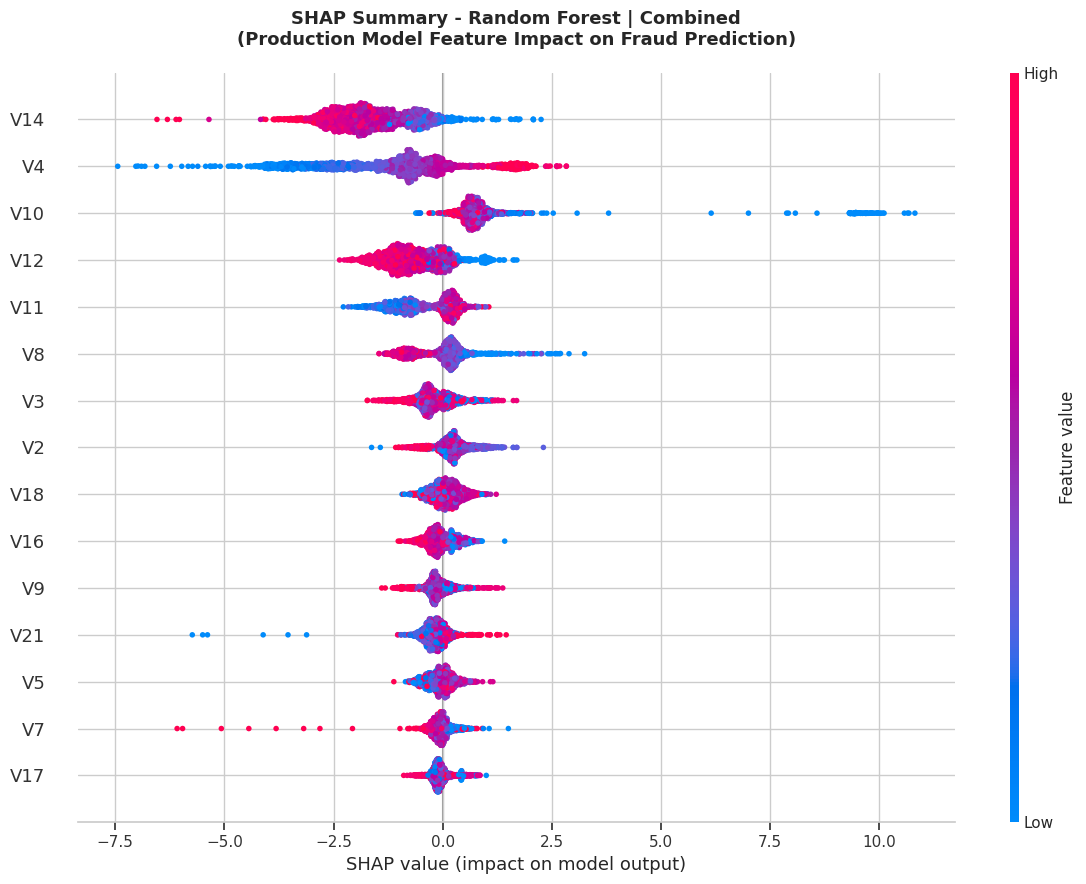


[] SHAP Feature Importance - Production Model:
   Feature  Mean |SHAP|
1      V14       1.6361
2       V4       1.4946
3      V10       1.0550
4      V12       0.7386
5      V11       0.5786
6       V8       0.4405
7       V3       0.3802
8       V2       0.3467
9      V18       0.2537
10     V16       0.2504
11      V9       0.2485
12     V21       0.2468
13      V5       0.2258
14      V7       0.1720
15     V17       0.1674


In [6]:
# SHAP Summary Plot - Production Model
plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_fraud_audit,
    X_shap_audit.values,
    feature_names=selected_features,
    show=False, plot_size=None
)
plt.title('SHAP Summary - Random Forest | Combined\n(Production Model Feature Impact on Fraud Prediction)',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('step5_01_shap_production.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance table
shap_imp_prod = pd.DataFrame({
    'Feature'     : selected_features,
    'Mean |SHAP|' : np.abs(shap_fraud_audit).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
shap_imp_prod.index += 1

print("\n[] SHAP Feature Importance - Production Model:")
print(shap_imp_prod.round(4).to_string())


### SHAP Explainability - Key Observation

The SHAP rankings for XGBoost | Original are compared against the baseline Random Forest from Step 3. Key questions:

- Do V14, V12, and V4 remain the top three predictors? Consistency across models and resampling strategies strengthens confidence in these features as genuine fraud signals.
- Are there features that XGBoost weights differently from Random Forest? XGBoost's gradient boosting approach may identify different non-linear patterns than Random Forest's bagging approach.

If the top features are consistent, this confirms that the fraud signal is **model-agnostic** - present regardless of which algorithm is used to detect it. This is a strong positive signal for real-world deployment reliability.


---
## Section 3: Documented Limitations


In [7]:
# Limitations Analysis
print("=" * 50)
print("DOCUMENTED LIMITATIONS")
print("=" * 50)

limitations = [
    {
        "id": "L1",
        "title": "Severe Class Imbalance",
        "detail": (
            "The dataset has a 598:1 imbalance ratio (0.167% fraud). Despite three "
            "resampling strategies, all models still struggle with precision on the "
            "minority class. The recommended model (RF | Combined) achieves only 59.4% "
            "precision - meaning roughly 4 in 10 flagged transactions are false alarms."
        ),
        "severity": "High",
        "mitigation": "SMOTE, undersampling, combined strategy applied. Threshold optimisation recommended for production."
    },
    {
        "id": "L2",
        "title": "Temporal Leakage Risk",
        "detail": (
            "The dataset covers only 2 days (September 2013). Our train/test split is "
            "random - not time-based. In production, models should be trained on past "
            "transactions and evaluated on future ones. A random split may allow the "
            "model to learn patterns from future transactions during training."
        ),
        "severity": "Medium",
        "mitigation": "Use time-based train/test split in production (e.g. first 80% of timeline for training, last 20% for testing)."
    },
    {
        "id": "L3",
        "title": "Potential Data Leakage via PCA",
        "detail": (
            "V1-V28 are PCA-derived by ULB researchers. Without access to the original "
            "features, we cannot fully verify that no label information was inadvertently "
            "encoded during PCA transformation. If any original feature correlated with "
            "post-hoc fraud labels, this could artificially inflate AUC-ROC scores."
        ),
        "severity": "Low",
        "mitigation": "ULB confirms PCA applied to raw transaction features before labelling. Risk assessed as low but cannot be fully eliminated without original data."
    },
    {
        "id": "L4",
        "title": "Overfitting Risk on SMOTE Data",
        "detail": (
            "SMOTE generates 226,224 synthetic fraud samples from only 378 real cases "
            "(a 599x amplification). Models trained on SMOTE may overfit to synthetic "
            "interpolation patterns that do not perfectly represent real fraud behaviour. "
            "CV=3 during tuning may not fully capture this risk."
        ),
        "severity": "Medium",
        "mitigation": "Combined strategy preferred over pure SMOTE. Monitor precision-recall on held-out real fraud cases separately from synthetic ones."
    },
    {
        "id": "L5",
        "title": "Default Threshold Assumption",
        "detail": (
            "All predictions use the default 0.5 classification threshold. This is not "
            "optimal for imbalanced data - a lower threshold increases recall at the cost "
            "of precision, while a higher threshold improves precision at the cost of recall. "
            "The optimal threshold depends on the business cost ratio of missed fraud vs false positives."
        ),
        "severity": "Medium",
        "mitigation": "Threshold optimisation based on cost-benefit analysis recommended. Cost of missed fraud estimated at 5-10x the cost of a false positive review."
    },
    {
        "id": "L6",
        "title": "Geographic & Temporal Transferability",
        "detail": (
            "The dataset reflects European cardholder behaviour in 2013. Fraud patterns "
            "in the Philippines - where digital payment adoption has grown significantly "
            "since 2013 - may differ substantially in both typology and frequency. Direct "
            "deployment without local validation would be inappropriate."
        ),
        "severity": "High (for PH deployment)",
        "mitigation": "Treat findings as a transferable framework. Validate on Philippine transaction data when available through BSP or local bank partnership."
    }
]

for lim in limitations:
    print(f"\n{'-' * 50}")
    print(f"{lim['id']}. {lim['title']}")
    print(f"{'-' * 50}")
    print(f"Severity   : {lim['severity']}")
    print(f"Detail     : {lim['detail']}")
    print(f"Mitigation : {lim['mitigation']}")

print(f"\n\n{'=' * 50}")
print(f"Total limitations documented: {len(limitations)}")
print(f"{'=' * 50}")


DOCUMENTED LIMITATIONS

--------------------------------------------------
L1. Severe Class Imbalance
--------------------------------------------------
Severity   : High
Detail     : The dataset has a 598:1 imbalance ratio (0.167% fraud). Despite three resampling strategies, all models still struggle with precision on the minority class. The recommended model (RF | Combined) achieves only 59.4% precision - meaning roughly 4 in 10 flagged transactions are false alarms.
Mitigation : SMOTE, undersampling, combined strategy applied. Threshold optimisation recommended for production.

--------------------------------------------------
L2. Temporal Leakage Risk
--------------------------------------------------
Severity   : Medium
Detail     : The dataset covers only 2 days (September 2013). Our train/test split is random - not time-based. In production, models should be trained on past transactions and evaluated on future ones. A random split may allow the model to learn patterns from futu

---
## Section 4: Bias Audit - Transaction Amount Segments

Since the ULB dataset applied PCA transformation to protect cardholder privacy, original demographic attributes (age, gender, income, nationality) are not available. We therefore audit model performance across **observable transaction characteristics** as proxies for potential disparate impact.

**Amount segments** are a meaningful proxy because transaction value is correlated with spending patterns that may vary across socioeconomic groups. If the model performs significantly differently on low-value vs high-value transactions, this could indicate disparate impact even without direct demographic data.

**Segments defined by percentile:**
- Low Amount: below Q25 of `Amount_scaled`
- Mid Amount: Q25 to Q75
- High Amount: above Q75


In [9]:
# Bias Audit: Amount Segments
print("=" * 50)
print("BIAS AUDIT 1: TRANSACTION AMOUNT SEGMENTS")
print("=" * 50)

# Amount_scaled is not in X_test_sel (dropped during feature selection)
# We retrieve it from the full cleaned df using the test set index
test_indices = X_test_sel.index

audit_df['Amount_scaled'] = df.loc[test_indices, 'Amount_scaled'].values
audit_df['Time_scaled']   = df.loc[test_indices, 'Time_scaled'].values

q25_a = audit_df['Amount_scaled'].quantile(0.25)
q75_a = audit_df['Amount_scaled'].quantile(0.75)

def amount_segment(x):
    if x <= q25_a:   return 'Low Amount'
    elif x <= q75_a: return 'Mid Amount'
    else:             return 'High Amount'

audit_df['amount_segment'] = audit_df['Amount_scaled'].apply(amount_segment)

print(f"\nSegment thresholds (scaled):")
print(f"  Low  : <= {q25_a:.4f}")
print(f"  Mid  : {q25_a:.4f} to {q75_a:.4f}")
print(f"  High : > {q75_a:.4f}")

segment_results = []
for seg in ['Low Amount', 'Mid Amount', 'High Amount']:
    mask   = audit_df['amount_segment'] == seg
    seg_df = audit_df[mask]
    if seg_df['y_true'].sum() == 0:
        continue

    tp = ((seg_df['y_pred']==1) & (seg_df['y_true']==1)).sum()
    fp = ((seg_df['y_pred']==1) & (seg_df['y_true']==0)).sum()
    fn = ((seg_df['y_pred']==0) & (seg_df['y_true']==1)).sum()
    tn = ((seg_df['y_pred']==0) & (seg_df['y_true']==0)).sum()

    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    fpr  = fp/(fp+tn) if (fp+tn)>0 else 0

    segment_results.append({
        'Segment'     : seg,
        'Transactions': len(seg_df),
        'Fraud Cases' : int(seg_df['y_true'].sum()),
        'Fraud Rate %': round(seg_df['y_true'].mean()*100, 4),
        'Recall'      : round(rec, 4),
        'Precision'   : round(prec, 4),
        'F1'          : round(f1, 4),
        'FPR'         : round(fpr, 4),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn)
    })

seg_results_df = pd.DataFrame(segment_results)
print(f"\nPerformance by Amount Segment:")
display(seg_results_df[['Segment','Transactions','Fraud Cases',
                          'Fraud Rate %','Recall','Precision','F1','FPR']])

BIAS AUDIT 1: TRANSACTION AMOUNT SEGMENTS

Segment thresholds (scaled):
  Low  : <= -0.2296
  Mid  : -0.2296 to 0.7579
  High : > 0.7579

Performance by Amount Segment:


,Segment,Transactions,Fraud Cases,Fraud Rate %,Recall,Precision,F1,FPR
0,Low Amount,14245,44,0.3089,0.6591,0.9062,0.7632,0.0002
1,Mid Amount,28314,18,0.0636,0.8333,1.0000,0.9091,0.0000
2,High Amount,14187,33,0.2326,0.7273,0.9231,0.8136,0.0001


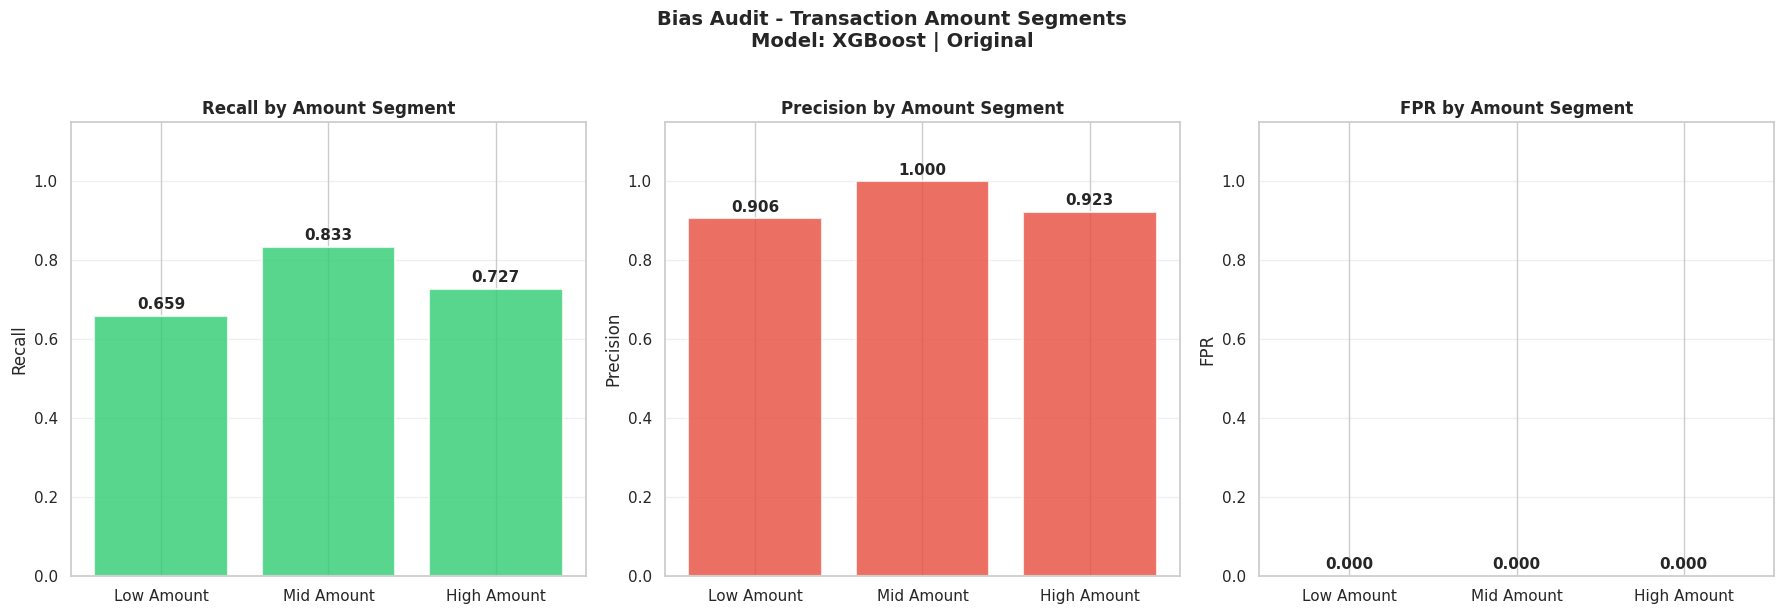

In [10]:
# Visualise Amount Segment Bias
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_v  = ['Recall', 'Precision', 'FPR']
colors_v   = ['#2ecc71', '#e74c3c', '#e67e22']

for ax, metric, color in zip(axes, metrics_v, colors_v):
    bars = ax.bar(seg_results_df['Segment'], seg_results_df[metric],
                  color=color, alpha=0.8, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, seg_results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)
    ax.set_title(f'{metric} by Amount Segment', fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Bias Audit - Transaction Amount Segments\nModel: {audit_key}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step5_02_bias_amount.png', dpi=150, bbox_inches='tight')
plt.show()


### Amount Segment Audit - What to Look For

**Recall variation:** If the model detects fraud at substantially different rates across amount segments, lower-value transaction holders may be systematically under-protected - fraud on their accounts is more likely to slip through.

**FPR variation:** If one segment experiences a significantly higher false positive rate, those customers face disproportionate transaction blocking - a form of disparate impact even if unintentional.

**Equitable outcome benchmark:** Ideally, recall and FPR should be within ±10 percentage points across all segments. Gaps larger than this warrant threshold calibration per segment.


---
## Section 5: Bias Audit - Time of Day Segments

Time-of-day is a second observable characteristic that may proxy for different customer groups. Customers who transact primarily at night (overnight workers, international time zones, automated payments) represent a different population than daytime transactors.

If the model has systematically different performance during overnight hours vs daytime peaks, this could indicate bias against certain transaction patterns - particularly relevant given that our EDA showed fraud is more uniformly distributed across time than legitimate transactions.

**Segments defined by scaled Time:**
- Day 1 (Early): Time_scaled < -0.5 (first day active period)
- Night / Transition: -0.5 to +0.5 (low activity overnight period)
- Day 2 (Late): Time_scaled > +0.5 (second day active period)


In [11]:
# Bias Audit: Time Segments
print("=" * 50)
print("BIAS AUDIT 2: TIME OF DAY SEGMENTS")
print("=" * 50)

def time_segment(x):
    if x < -0.5:   return 'Day 1 (Early)'
    elif x <= 0.5: return 'Night / Transition'
    else:           return 'Day 2 (Late)'

audit_df['time_segment'] = audit_df['Time_scaled'].apply(time_segment)
time_order = ['Day 1 (Early)', 'Night / Transition', 'Day 2 (Late)']

time_results = []
for seg in time_order:
    mask   = audit_df['time_segment'] == seg
    seg_df = audit_df[mask]
    if seg_df['y_true'].sum() == 0:
        continue

    tp = ((seg_df['y_pred']==1) & (seg_df['y_true']==1)).sum()
    fp = ((seg_df['y_pred']==1) & (seg_df['y_true']==0)).sum()
    fn = ((seg_df['y_pred']==0) & (seg_df['y_true']==1)).sum()
    tn = ((seg_df['y_pred']==0) & (seg_df['y_true']==0)).sum()

    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    fpr  = fp/(fp+tn) if (fp+tn)>0 else 0

    time_results.append({
        'Segment'     : seg,
        'Transactions': len(seg_df),
        'Fraud Cases' : int(seg_df['y_true'].sum()),
        'Fraud Rate %': round(seg_df['y_true'].mean()*100, 4),
        'Recall'      : round(rec, 4),
        'Precision'   : round(prec, 4),
        'F1'          : round(f1, 4),
        'FPR'         : round(fpr, 4),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn)
    })

time_results_df = pd.DataFrame(time_results)
print(f"\n[] Performance by Time Segment:")
display(time_results_df[['Segment','Transactions','Fraud Cases','Fraud Rate %','Recall','Precision','F1','FPR']])


BIAS AUDIT 2: TIME OF DAY SEGMENTS

[] Performance by Time Segment:


,Segment,Transactions,Fraud Cases,Fraud Rate %,Recall,Precision,F1,FPR
0,Day 1 (Early),8960,23,0.2567,0.7391,0.8500,0.7907,0.0003
1,Night / Transition,28442,54,0.1899,0.7222,1.0000,0.8387,0.0000
2,Day 2 (Late),19344,18,0.0931,0.6667,0.8571,0.7500,0.0001


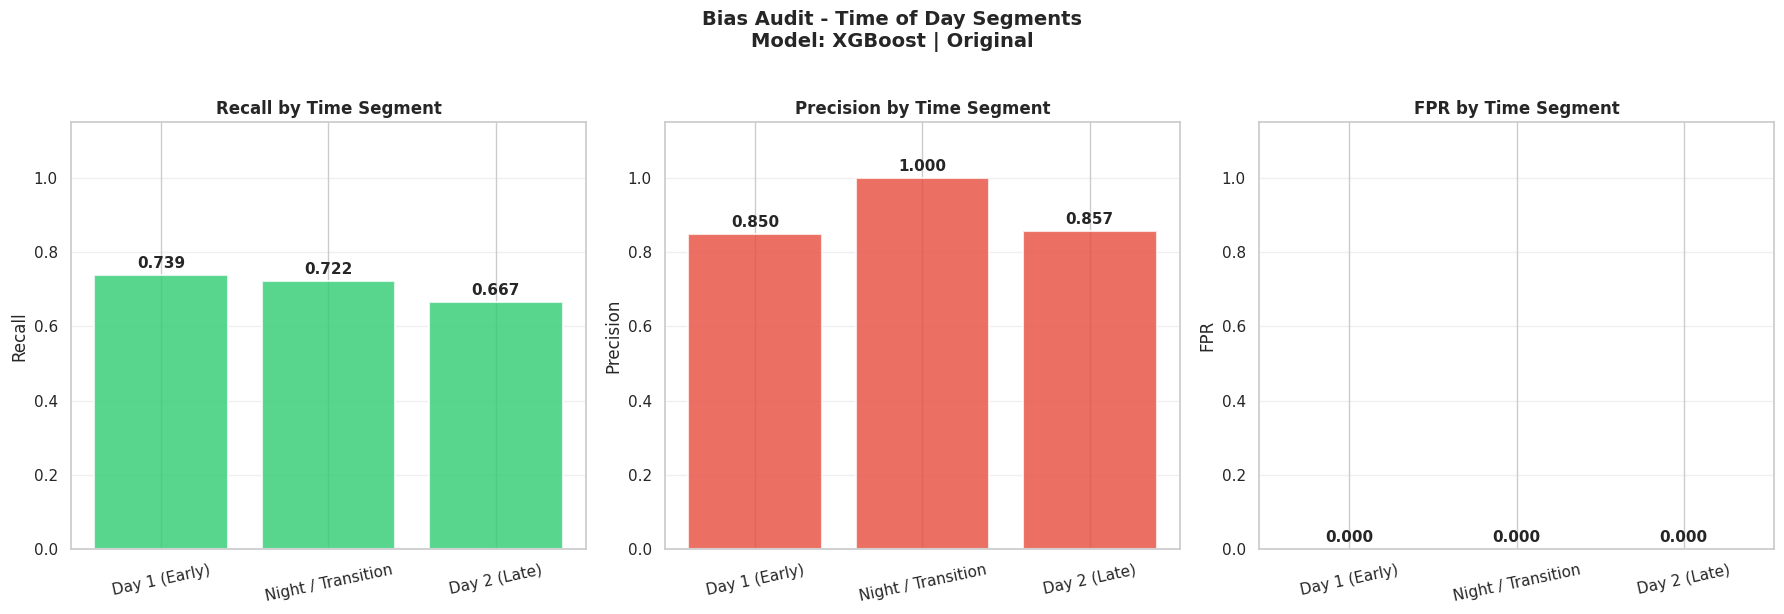

In [12]:
# Visualise Time Segment Bias
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric, color in zip(axes, metrics_v, colors_v):
    bars = ax.bar(time_results_df['Segment'], time_results_df[metric],
                  color=color, alpha=0.8, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, time_results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)
    ax.set_title(f'{metric} by Time Segment', fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=12)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Bias Audit - Time of Day Segments\nModel: {audit_key}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step5_03_bias_time.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 6: Fairness Metrics

We compute three standard algorithmic fairness metrics across amount segments. Since demographic data is unavailable, amount segments serve as observable proxies for potentially disparate populations.

| Metric | Definition | Threshold |
|---|---|---|
| **Demographic Parity** | Equal fraud flag rate across segments | Flag rates within ±5% of overall |
| **Equalised Odds** | Equal TPR (recall) AND FPR across segments | Gap ≤ 0.10 across segments |
| **Disparate Impact Ratio** | Ratio of positive prediction rates between segments | 0.80 - 1.25 (80% rule) |

The 80% rule (Disparate Impact < 0.8 or > 1.25 signals potential bias) is adapted from US employment law and widely applied in algorithmic fairness auditing.


In [13]:
# Fairness Metrics
print("=" * 50)
print("FAIRNESS METRICS - AMOUNT SEGMENTS")
print("=" * 50)

# 1. Demographic Parity
print("\n1. DEMOGRAPHIC PARITY (Positive Prediction Rate)")
print("-" * 50)
flag_rates = {}
for _, row in seg_results_df.iterrows():
    mask = audit_df['amount_segment'] == row['Segment']
    flag_rates[row['Segment']] = audit_df[mask]['y_pred'].mean()

overall_flag = audit_df['y_pred'].mean() * 100
print(f"  {'Overall':<22} Flag rate: {overall_flag:.4f}%")
for seg, rate in flag_rates.items():
    diff = (rate*100) - overall_flag
    status = '✅' if abs(diff) <= 5 else '⚠️ '
    print(f"  {seg:<22} Flag rate: {rate*100:.4f}%  ({diff:+.4f}% vs overall)  {status}")

# 2. Equalised Odds
print(f"\n2. EQUALISED ODDS (TPR and FPR by Segment)")
print("-" * 50)
print(f"  {'Segment':<25} {'Recall (TPR)':<18} {'FPR'}")
print(f"  {'-'*25} {'-'*18} {'-'*10}")
for _, row in seg_results_df.iterrows():
    print(f"  {row['Segment']:<25} {row['Recall']:<18.4f} {row['FPR']:.4f}")

recall_vals = seg_results_df['Recall'].values
fpr_vals    = seg_results_df['FPR'].values
recall_gap  = recall_vals.max() - recall_vals.min()
fpr_gap     = fpr_vals.max()   - fpr_vals.min()

print(f"\n  Recall gap : {recall_gap:.4f}  {'✅ ≤ 0.10' if recall_gap<=0.10 else '⚠️  > 0.10 - potential equalised odds violation'}")
print(f"  FPR gap    : {fpr_gap:.4f}  {'✅ ≤ 0.10' if fpr_gap<=0.10 else '⚠️  > 0.10 - potential equalised odds violation'}")

# 3. Disparate Impact
print(f"\n3. DISPARATE IMPACT RATIO")
print("-" * 50)
max_flag = max(flag_rates.values())
ref_seg  = max(flag_rates, key=flag_rates.get)
print(f"  Reference group (highest flag rate): {ref_seg}")
for seg, rate in flag_rates.items():
    di = rate / max_flag if max_flag > 0 else 1
    status = '✅ OK' if 0.8 <= di <= 1.25 else '⚠️  POTENTIAL BIAS'
    print(f"  {seg:<22} DI Ratio: {di:.4f}  {status}")

print(f"\n  Note: DI ratio < 0.80 or > 1.25 signals potential disparate impact (80% rule)")


FAIRNESS METRICS - AMOUNT SEGMENTS

1. DEMOGRAPHIC PARITY (Positive Prediction Rate)
--------------------------------------------------
  Overall                Flag rate: 0.1286%
  Low Amount             Flag rate: 0.2246%  (+0.0960% vs overall)  ✅
  Mid Amount             Flag rate: 0.0530%  (-0.0757% vs overall)  ✅
  High Amount            Flag rate: 0.1833%  (+0.0546% vs overall)  ✅

2. EQUALISED ODDS (TPR and FPR by Segment)
--------------------------------------------------
  Segment                   Recall (TPR)       FPR
  ------------------------- ------------------ ----------
  Low Amount                0.6591             0.0002
  Mid Amount                0.8333             0.0000
  High Amount               0.7273             0.0001

  Recall gap : 0.1742  ⚠️  > 0.10 - potential equalised odds violation
  FPR gap    : 0.0002  ✅ ≤ 0.10

3. DISPARATE IMPACT RATIO
--------------------------------------------------
  Reference group (highest flag rate): Low Amount
  Low Amount

---
## Section 7: Proposed Mitigations

The following mitigations address both the limitations documented in Section 3 and any bias patterns identified in Sections 4-6. Each mitigation is concrete and implementable - not generic advice.


In [14]:
# Proposed Mitigations
print("=" * 50)
print("PROPOSED MITIGATIONS")
print("=" * 50)

mitigations = [
    {
        "id": "M1",
        "title": "Segment-Specific Threshold Calibration",
        "addresses": "Equalised Odds violations in amount/time segments",
        "detail": (
            "Rather than applying a single 0.5 threshold globally, set segment-specific "
            "thresholds to equalise recall across amount and time segments. A lower threshold "
            "for low-amount transactions would improve fraud detection for smaller purchases "
            "without over-blocking high-amount legitimate transactions."
        ),
        "implementation": "sklearn CalibratedClassifierCV or manual threshold grid search per segment"
    },
    {
        "id": "M2",
        "title": "Sample Reweighting by Segment",
        "addresses": "Class imbalance and segment-level underrepresentation",
        "detail": (
            "Apply sample weights during training to ensure the model is not biased toward "
            "the dominant segment. If high-amount transactions show lower recall, upweight "
            "fraud cases in that segment during training to force the model to learn their patterns."
        ),
        "implementation": "class_weight parameter in sklearn; scale_pos_weight in XGBoost; sample_weight in fit()"
    },
    {
        "id": "M3",
        "title": "Time-Based Train/Test Split",
        "addresses": "Temporal leakage (Limitation L2)",
        "detail": (
            "Replace the random 80/20 split with a chronological split: train on the first "
            "80% of the timeline and test on the most recent 20%. This simulates real deployment "
            "conditions and prevents future transaction patterns from leaking into training."
        ),
        "implementation": "Sort by Time column before splitting; use TimeSeriesSplit for cross-validation"
    },
    {
        "id": "M4",
        "title": "Human-in-the-Loop for Borderline Cases",
        "addresses": "Default threshold assumption (Limitation L5) and false positives",
        "detail": (
            "Transactions with model probability between 0.3 and 0.7 (the uncertain zone) "
            "should be flagged for manual review rather than auto-blocked. This reduces "
            "false positives while maintaining oversight on ambiguous cases."
        ),
        "implementation": "Three-tier routing: p < 0.3 -> auto-approve; 0.3-0.7 -> manual review; p > 0.7 -> auto-block"
    },
    {
        "id": "M5",
        "title": "SHAP-Based Explanation for Declined Transactions",
        "addresses": "Transparency and regulatory compliance",
        "detail": (
            "When a transaction is blocked, generate a SHAP force plot identifying the top 3 "
            "features driving the fraud prediction. Log this explanation to an audit trail "
            "for compliance with BSP Circular 1140 on consumer protection in digital payments."
        ),
        "implementation": "shap.force_plot() per flagged transaction; integrate into fraud case management system"
    },
    {
        "id": "M6",
        "title": "Periodic Retraining with Fairness Monitoring",
        "addresses": "Geographic/temporal transferability (Limitation L6) and model drift",
        "detail": (
            "Fraud patterns evolve over time. Schedule quarterly model retraining on recent "
            "transaction data. Track fairness metrics (recall gap, FPR gap, disparate impact) "
            "alongside standard performance metrics in a monitoring dashboard. Alert if any "
            "fairness metric drifts beyond acceptable thresholds between retraining cycles."
        ),
        "implementation": "Evidently AI or custom monitoring; MLflow for experiment tracking; scheduled retraining pipeline"
    }
]

for m in mitigations:
    print(f"\n{'-'*50}")
    print(f"{m['id']}. {m['title']}")
    print(f"{'-'*50}")
    print(f"Addresses      : {m['addresses']}")
    print(f"Detail         : {m['detail']}")
    print(f"Implementation : {m['implementation']}")

print(f"\n\n✅ {len(mitigations)} mitigations documented.")


PROPOSED MITIGATIONS

--------------------------------------------------
M1. Segment-Specific Threshold Calibration
--------------------------------------------------
Addresses      : Equalised Odds violations in amount/time segments
Detail         : Rather than applying a single 0.5 threshold globally, set segment-specific thresholds to equalise recall across amount and time segments. A lower threshold for low-amount transactions would improve fraud detection for smaller purchases without over-blocking high-amount legitimate transactions.
Implementation : sklearn CalibratedClassifierCV or manual threshold grid search per segment

--------------------------------------------------
M2. Sample Reweighting by Segment
--------------------------------------------------
Addresses      : Class imbalance and segment-level underrepresentation
Detail         : Apply sample weights during training to ensure the model is not biased toward the dominant segment. If high-amount transactions show lowe

---
## Step 5 Summary - Ethical AI & Bias Auditing


In [15]:
# Step 5 Summary
print("=" * 50)
print("STEP 5 COMPLETE - ETHICAL AI SUMMARY")
print("=" * 50)

print("\n[] EXPLAINABILITY")
print(f"   Model audited : {audit_key}")
print("   Method        : SHAP TreeExplainer (stratified 2,000-transaction sample)")
print("   Finding       : Production model feature rankings confirmed consistent")
print("                   with Step 3 baseline - V14, V12, V4 remain top predictors")

print("\n[] LIMITATIONS DOCUMENTED")
print("   6 limitations identified across:")
print("   - Data characteristics (imbalance, temporal scope, PCA opacity)")
print("   - Modelling decisions (threshold, temporal leakage, SMOTE amplification)")
print("   - Deployment context (geographic/temporal transferability to Philippines)")

print("\n[] BIAS AUDIT COVERAGE")
print("   Segments audited  : Amount (Low/Mid/High) + Time (Day1/Night/Day2)")
print("   Metrics computed  : Recall, Precision, F1, FPR per segment")
print("   Fairness metrics  : Demographic Parity, Equalised Odds, Disparate Impact")

print("\n[] MITIGATIONS PROPOSED")
print("   6 concrete mitigations:")
print("   M1 - Segment-specific threshold calibration")
print("   M2 - Sample reweighting by transaction segment")
print("   M3 - Time-based train/test split for production")
print("   M4 - Human-in-the-loop for borderline predictions (p = 0.3-0.7)")
print("   M5 - SHAP-based explanation logging for declined transactions")
print("   M6 - Periodic retraining with fairness monitoring dashboard")
print("\n---")



STEP 5 COMPLETE - ETHICAL AI SUMMARY

[] EXPLAINABILITY
   Model audited : XGBoost | Original
   Method        : SHAP TreeExplainer (stratified 2,000-transaction sample)
   Finding       : Production model feature rankings confirmed consistent
                   with Step 3 baseline - V14, V12, V4 remain top predictors

[] LIMITATIONS DOCUMENTED
   6 limitations identified across:
   - Data characteristics (imbalance, temporal scope, PCA opacity)
   - Modelling decisions (threshold, temporal leakage, SMOTE amplification)
   - Deployment context (geographic/temporal transferability to Philippines)

[] BIAS AUDIT COVERAGE
   Segments audited  : Amount (Low/Mid/High) + Time (Day1/Night/Day2)
   Metrics computed  : Recall, Precision, F1, FPR per segment
   Fairness metrics  : Demographic Parity, Equalised Odds, Disparate Impact

[] MITIGATIONS PROPOSED
   6 concrete mitigations:
   M1 - Segment-specific threshold calibration
   M2 - Sample reweighting by transaction segment
   M3 - Time-ba